## 8.3)
Writing a program to evaluate the sample mean vs. the sample median for a Pareto distribution using 100 bootstrap replicates

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Theoretical mean: 21.0000
Theoretical median: 1.9351
Original sample mean: 6.0122
Original sample median: 1.8396

Bootstrap variance of the mean: 2.7935
Bootstrap variance of the median: 0.0093


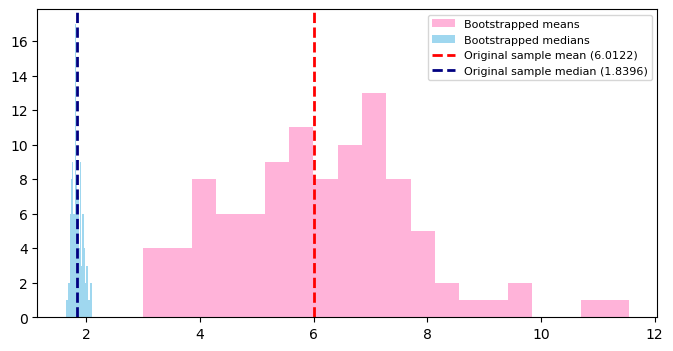

In [4]:
np.random.seed(2443)

# Defining the parameters
n_83 = 200  # Number of samples
k_83 = 1.05 # The k parameter in the pareto distribution
beta_83 = 1.0   # The beta parameter in the pareto distribution
k_boot = 100 # bootstrap replicates

# Generate Pareto data 
# To get a standard Pareto starting at beta we add 1 and multiply by beta.
pareto_data = (np.random.pareto(k_83, n_83) + 1) * beta_83


# Theoretical mean
theoretical_mean = (k_83 * beta_83) / (k_83 - 1)

# Theoretical median
theoretical_median = beta_83 * (2 ** (1 / k_83))

# 1. Compute the sample mean and sample median
sample_mean_83 = np.mean(pareto_data)
sample_median_83 = np.median(pareto_data)


# Bootstrap process
boot_means_pareto = np.zeros(k_boot)    # Creats an array to store the bootstrap means
boot_medians_pareto = np.zeros(k_boot)  # Creats an array to store the bootstrap medians

for i in range(k_boot):
    boot_samp = np.random.choice(pareto_data, size=n_83, replace=True)  # Creating 200 bootstrap samples, by sampling with replacement
    boot_means_pareto[i] = np.mean(boot_samp)   # Adding the bootstrap sample means to the storage array
    boot_medians_pareto[i] = np.median(boot_samp)   # Adding the bootstrap medians to the storage array

# 2. + 3. Estimating the variance of the sample mean and median using the bootstrap replicates
var_of_mean = np.var(boot_means_pareto, ddof=1) # The variance of the bootstrap sample means
var_of_median = np.var(boot_medians_pareto, ddof=1) # The variance of the bootstrap sample medians

# Printing some results
print(f"Theoretical mean: {theoretical_mean:.4f}")  # The theoretical mean 
print(f"Theoretical median: {theoretical_median:.4f}")  # The theoretical median
print(f"Original sample mean: {sample_mean_83:.4f}")    # Printing the sample mean
print(f"Original sample median: {sample_median_83:.4f}\n")  # Printing the sample median
print(f"Bootstrap variance of the mean: {var_of_mean:.4f}") # The estimate of the variance of the sample mean using the bootstrap method
print(f"Bootstrap variance of the median: {var_of_median:.4f}") # The estimate of the variance of the sample median using the bootstrap method



# Plotting the distributions of the bootstrap estimators to visualize precision
plt.figure(figsize=(8, 4))
plt.hist(boot_means_pareto, bins=20, alpha=0.5, label='Bootstrapped means', color='hotpink')
plt.hist(boot_medians_pareto, bins=20, alpha=0.8, label='Bootstrapped medians', color='skyblue')

plt.axvline(sample_mean_83, color='red', linestyle='dashed', linewidth=2, 
            label=f'Original sample mean ({sample_mean_83:.4f})')
            
plt.axvline(sample_median_83, color='navy', linestyle='dashed', linewidth=2, 
            label=f'Original sample median ({sample_median_83:.4f})')

#plt.title("Distribution of bootstrapped estimates")
plt.legend(fontsize=8)
plt.show()